# Perfiles de clientes Premium dados de baja — segmentación por reglas de negocio

**Para:** presentación ejecutiva a Miranda Wintour (Directora Comercial)
**Base:** los 4.067 clientes BAJA+2 de marzo a junio de 2021, con toda su historia en el banco, comparados contra los clientes que siguen ("cliente fiel").

Este notebook reemplaza el enfoque anterior (agrupamiento vía Random Forest + k-means, ver `eda.ipynb`) por una **segmentación de reglas de negocio simples**, derivada de ese mismo análisis exploratorio pero traducida a una lógica que cualquiera en el banco puede auditar a mano: cada cliente cae en **un solo** perfil, siguiendo un orden de prioridad de 5 preguntas de sí/no. La segmentación por reglas reproduce el 87% de las asignaciones del agrupamiento original — se prefiere acá por ser más simple de explicar y de mantener, no porque sea "más precisa".

Los datos ya están procesados por [`perfiles_baja2.py`](perfiles_baja2.py) (script reproducible: `python perfiles_baja2.py --csv data/competencia_01.csv --out perfiles_baja2`). Este notebook consume esos resultados (`perfiles_baja2/*.csv` y los gráficos `.png` ya generados) y arma el relato de negocio sobre esa base.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, ".")
import perfiles_baja2 as pb  # para reutilizar los nombres y colores de los 5 perfiles

DIR = Path("perfiles_baja2")

tabla = pd.read_csv(DIR / "tabla_perfiles.csv", index_col=0)
clientes_perfil = pd.read_csv(DIR / "cliente_perfil.csv")
tray = pd.read_csv(DIR / "trayectorias_perfiles.csv")
tray_fieles = pd.read_csv(DIR / "trayectorias_fieles.csv")

ORDEN_PERFILES = [pb.PERFILES[c][0] for c in pb.PERFILES]  # orden fijo = mismo orden/color que los gráficos
COLOR_PERFIL = {pb.PERFILES[c][0]: pb.PERFILES[c][1] for c in pb.PERFILES}
CODIGO_PERFIL = {pb.PERFILES[c][0]: c for c in pb.PERFILES}

def img(nombre, width=1000):
    display(Image(filename=str(DIR / nombre), width=width))

pd.set_option("display.float_format", lambda v: f"{v:,.1f}")


## 1. El costo de la inacción

¿Cuánto nos cuesta, en plata, dejar que esto siga pasando al ritmo actual?


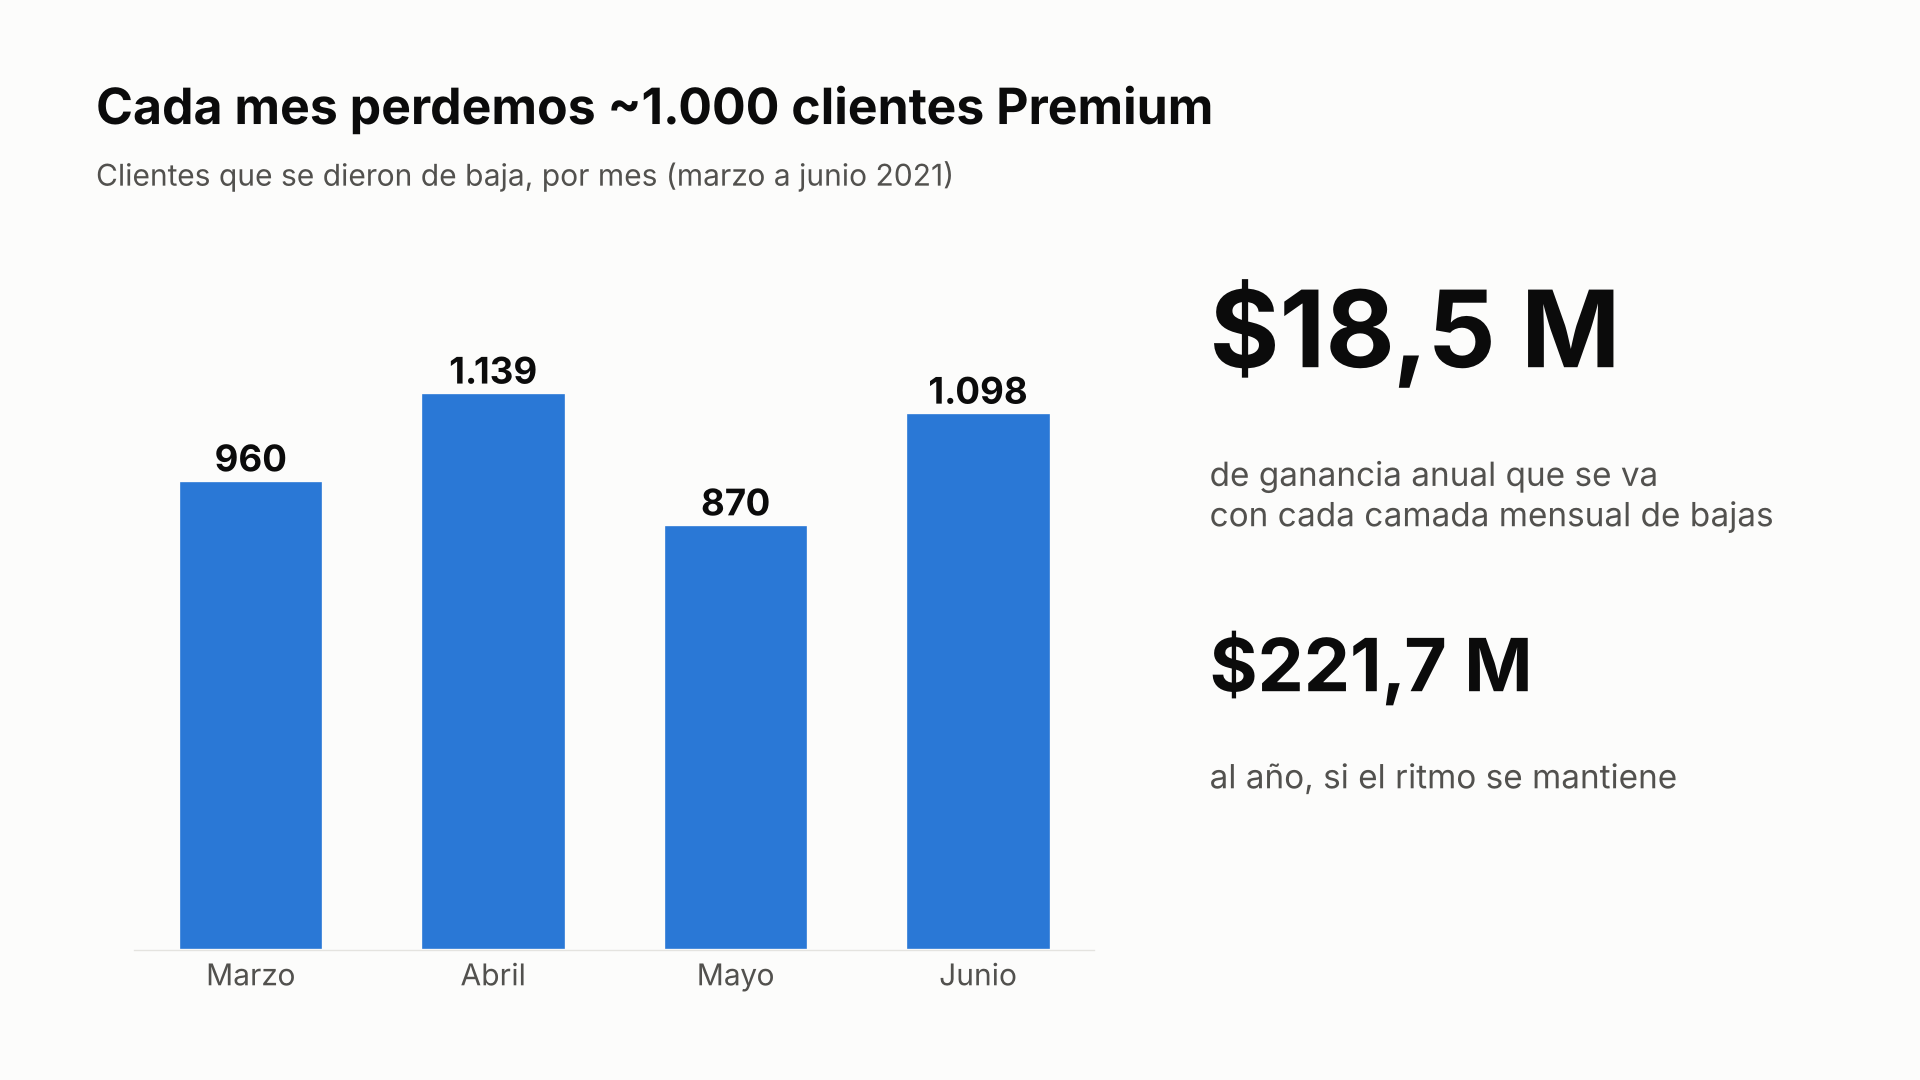

In [2]:
img("00_gancho_perdida.png")

In [3]:
rent = tabla.loc["rentabilidad_anual_mediana"]
mito = pd.DataFrame({
    "Rentabilidad anual típica (mediana por cliente)": {
        "Cliente que se fue (todos)": rent["TODOS_BAJA2"],
        "Cliente fiel": rent["CLIENTE_FIEL"],
        "Perfil \"El endeudado sin red\"": rent["El endeudado sin red"],
    }
}).T

(mito.style
    .format("${:,.0f}")
    .set_caption("Mito a romper: \"el que se va no nos dejaba nada\"")
    .set_table_styles([{"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"), ("text-align", "left")]}]))


,Cliente que se fue (todos),Cliente fiel,"Perfil ""El endeudado sin red"""
Rentabilidad anual típica (mediana por cliente),"$9,962","$13,020","$19,035"


**La lectura:** un cliente que se da de baja no es, en el momento de irse, un cliente de rentabilidad negativa ni despreciable — deja en promedio **$10 mil anuales**, un 77% de lo que deja un cliente fiel ($13 mil). Y el perfil "endeudado sin red" deja **$19 mil**, por encima incluso del fiel promedio. No se van los clientes que ya no nos convenían: se van clientes rentables que no estamos reteniendo.


## 2. La foto común, dos meses antes de la baja

Antes de ver en qué se diferencian, ¿qué tienen en común **todos** los que se van, más allá del perfil?


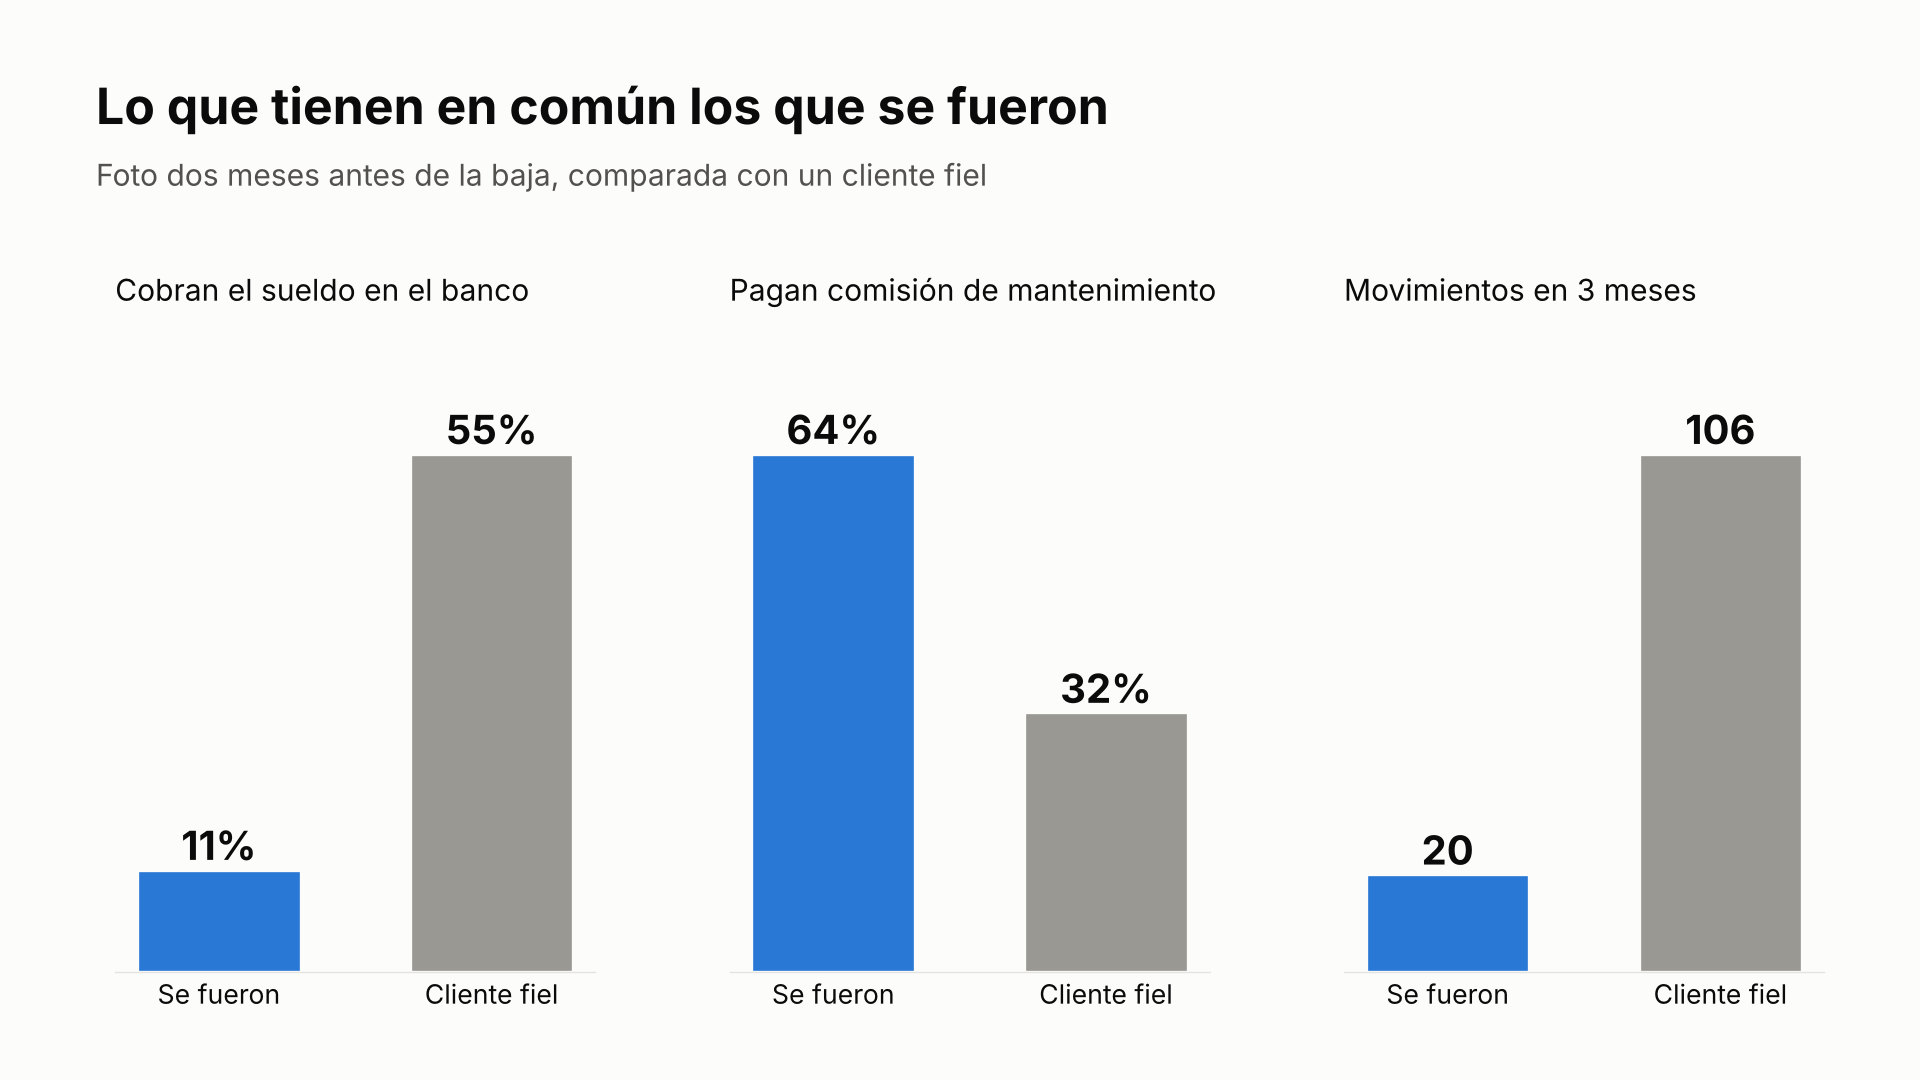

In [4]:
img("02_patron_comun.png")

In [5]:
comun = pd.DataFrame({
    "Se fueron": tabla.loc[["pct_cobra_sueldo", "pct_paga_comision_mant", "movimientos_trimestre_mediana", "pct_cuenta_en_rojo"], "TODOS_BAJA2"],
    "Cliente fiel": tabla.loc[["pct_cobra_sueldo", "pct_paga_comision_mant", "movimientos_trimestre_mediana", "pct_cuenta_en_rojo"], "CLIENTE_FIEL"],
})
comun.index = ["Cobran el sueldo en el banco", "Pagan comisión de mantenimiento", "Movimientos en 3 meses (mediana)", "Cuenta corriente en rojo"]

(comun.style
    .format({"Se fueron": lambda v: f"{v:.0%}" if v <= 1 else f"{v:,.0f}",
             "Cliente fiel": lambda v: f"{v:.0%}" if v <= 1 else f"{v:,.0f}"})
    .set_caption("BAJA+2 vs. cliente fiel, dos meses antes de la baja")
    .set_table_styles([{"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"), ("text-align", "left")]}]))


,Se fueron,Cliente fiel
Cobran el sueldo en el banco,11%,55%
Pagan comisión de mantenimiento,64%,32%
Movimientos en 3 meses (mediana),20,106
Cuenta corriente en rojo,69%,44%


**Conclusión estratégica:** el que se va casi nunca tiene el sueldo atado al banco (11% vs. 55%), usa la cuenta una quinta parte de lo que la usa un fiel (20 vs. 106 movimientos), y tiene 1,6 veces más chances de estar en descubierto. Y a ese cliente — el que menos valor percibe, el que no tiene el ancla del sueldo — le cobramos **el doble** de comisión de mantenimiento que a un fiel (64% vs. 32%). Le cobramos más justo a quien menos atados estamos reteniendo.


## 3. Mapa de segmentación: 5 historias, no una sola

Tratar a todos los que se van como "un solo problema" lleva a una sola solución genérica. Separamos a los 4.067 clientes en 5 perfiles con una lógica de **5 preguntas de sí/no, en orden de prioridad** — cada cliente cae en la primera que le aplica:

1. ¿Cobró el sueldo en el banco en algún mes observado? → **El sueldo que se muda**
2. ¿Tiene un préstamo vigente o la tarjeta en mora? → **El endeudado sin red**
3. ¿No usa ni la tarjeta de débito ni la de crédito? → **El fantasma que paga**
4. ¿Usa la tarjeta de débito? → **El ahorrista digital castigado**
5. Lo que queda (sólo usa la tarjeta de crédito) → **El cliente de una sola tarjeta**

*Nota técnica (para quien audite el método, no para el video):* estas reglas se derivaron de una segmentación exploratoria con 17 variables de negocio y reproducen el 87% de esas asignaciones (estabilidad por remuestreo: ARI promedio 0,77). Se prefieren las reglas explícitas porque cualquier persona del banco puede mirar a un cliente y saber en qué perfil cae, sin depender de un modelo.


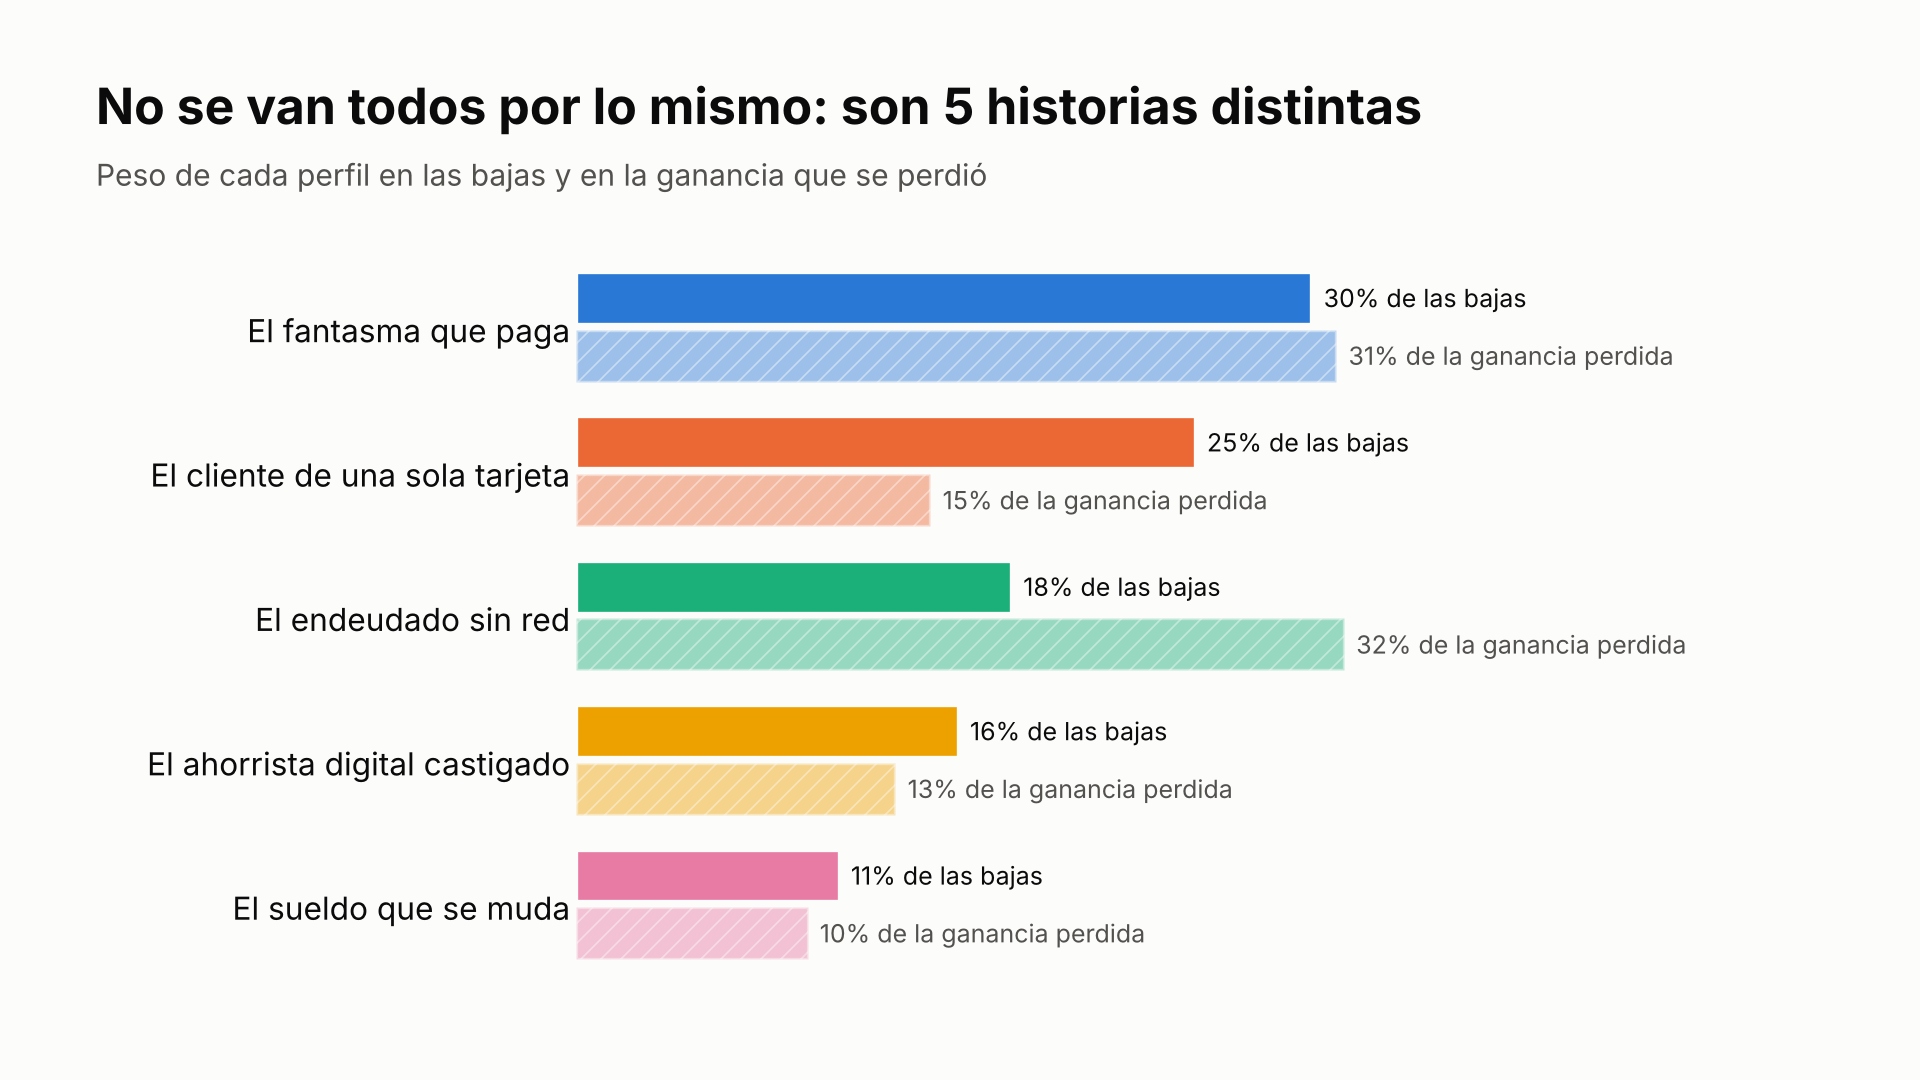

In [6]:
img("01_mapa_perfiles.png")

In [7]:
mapa = tabla.loc[["clientes", "pct_de_las_bajas", "pct_de_la_rentabilidad_perdida", "rentabilidad_anual_mediana"], ORDEN_PERFILES].T
mapa.columns = ["Clientes", "% de las bajas", "% de la ganancia perdida", "Rentabilidad anual típica"]
mapa = mapa.sort_values("% de las bajas", ascending=False)

(mapa.style
    .format({"Clientes": "{:,.0f}", "% de las bajas": "{:.0%}", "% de la ganancia perdida": "{:.0%}", "Rentabilidad anual típica": "${:,.0f}"})
    .bar(subset=["% de las bajas"], color=COLOR_PERFIL[mapa.index[0]] + "55", vmin=0)
    .set_caption("Matriz resumen de los 5 perfiles")
    .set_table_styles([{"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"), ("text-align", "left")]}]))


,Clientes,% de las bajas,% de la ganancia perdida,Rentabilidad anual típica
El fantasma que paga,"1,229",30%,31%,"$10,271"
El cliente de una sola tarjeta,"1,034",25%,15%,"$6,984"
El endeudado sin red,727,18%,32%,"$19,035"
El ahorrista digital castigado,638,16%,13%,"$8,338"
El sueldo que se muda,439,11%,10%,"$7,385"


Dos perfiles concentran casi dos tercios (63%) de la plata que se perdió: **el fantasma** (31%) y **el endeudado** (32%) — y no son el mismo problema: uno es desuso total, el otro es sobre-endeudamiento. Van en detalle a continuación.


## 4. Los cinco perfiles en profundidad


### Perfil 1 · El fantasma que paga (30% de las bajas, 31% de la ganancia perdida)

**Quién es:** tiene el paquete pero no lo usa — no consume ni con la tarjeta de débito ni con la de crédito. Es el de menor antigüedad de los cinco (69 meses contra 127 de un fiel).

**Variables que lo definen:**

- Movimientos en 3 meses: **4** (fiel: 106). El 70% hace menos de 10.
- Cuenta corriente en rojo: **81%** (fiel: 43%); el rojo crece mes a mes, de $6,7 mil a $11,3 mil promedio antes de irse.
- Paga comisión de mantenimiento: **74%** (fiel: 32%); esa proporción sube del 63% al 82% en los últimos 4 meses.
- Uso de Homebanking/app: 38% (fiel: 94%).

**La historia:** nunca lo activamos. La única relación que tiene con el banco es una comisión y un descubierto que crece. Igual deja $10 mil por año, casi como un fiel — cobrados "por nada". Ese es exactamente el motivo para irse.

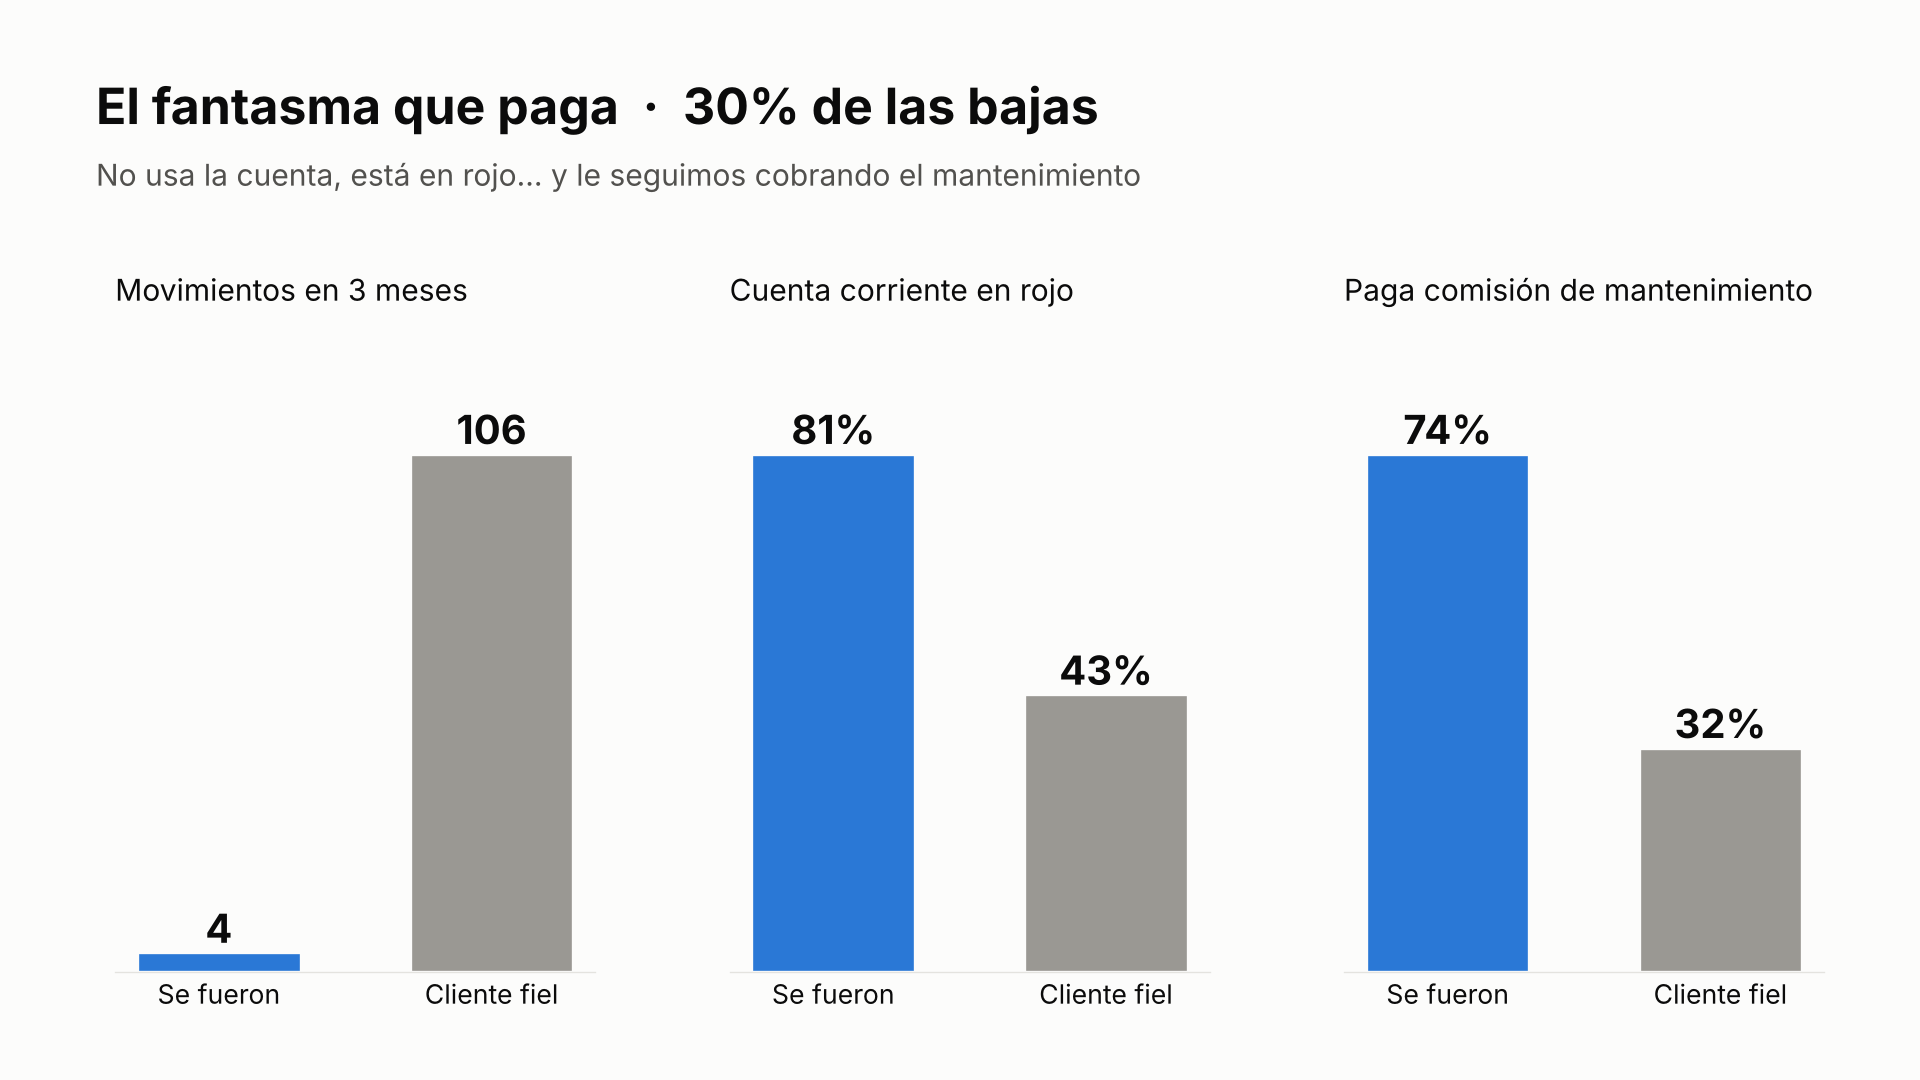

In [8]:
img("03_perfil_fantasma.png")

### Perfil 2 · El cliente de una sola tarjeta (25% de las bajas, 15% de la ganancia perdida)

**Quién es:** usa **sólo** la tarjeta de crédito: el 100% consume con ella y ninguno usa la de débito. No cobra el sueldo en el banco. Es antiguo (110 meses).

**Variables que lo definen:**

- Consumo con tarjeta **estable hasta el final**: unos $21 mil por mes, de punta a punta — no se "apaga".
- Le cobramos mantenimiento a una proporción cada vez mayor: **59% → 64% → 72% → 82%**, mientras en el fiel queda plano en 32%.
- Operaciones digitales: 9 por mes (fiel: 26).

**La historia:** no se va por desuso, se va **usando** la tarjeta. Para él, el paquete *es* la tarjeta. Cuando empieza a pagar mantenimiento por un paquete del que sólo usa una pieza, se va a una tarjeta sin costo de otro banco.

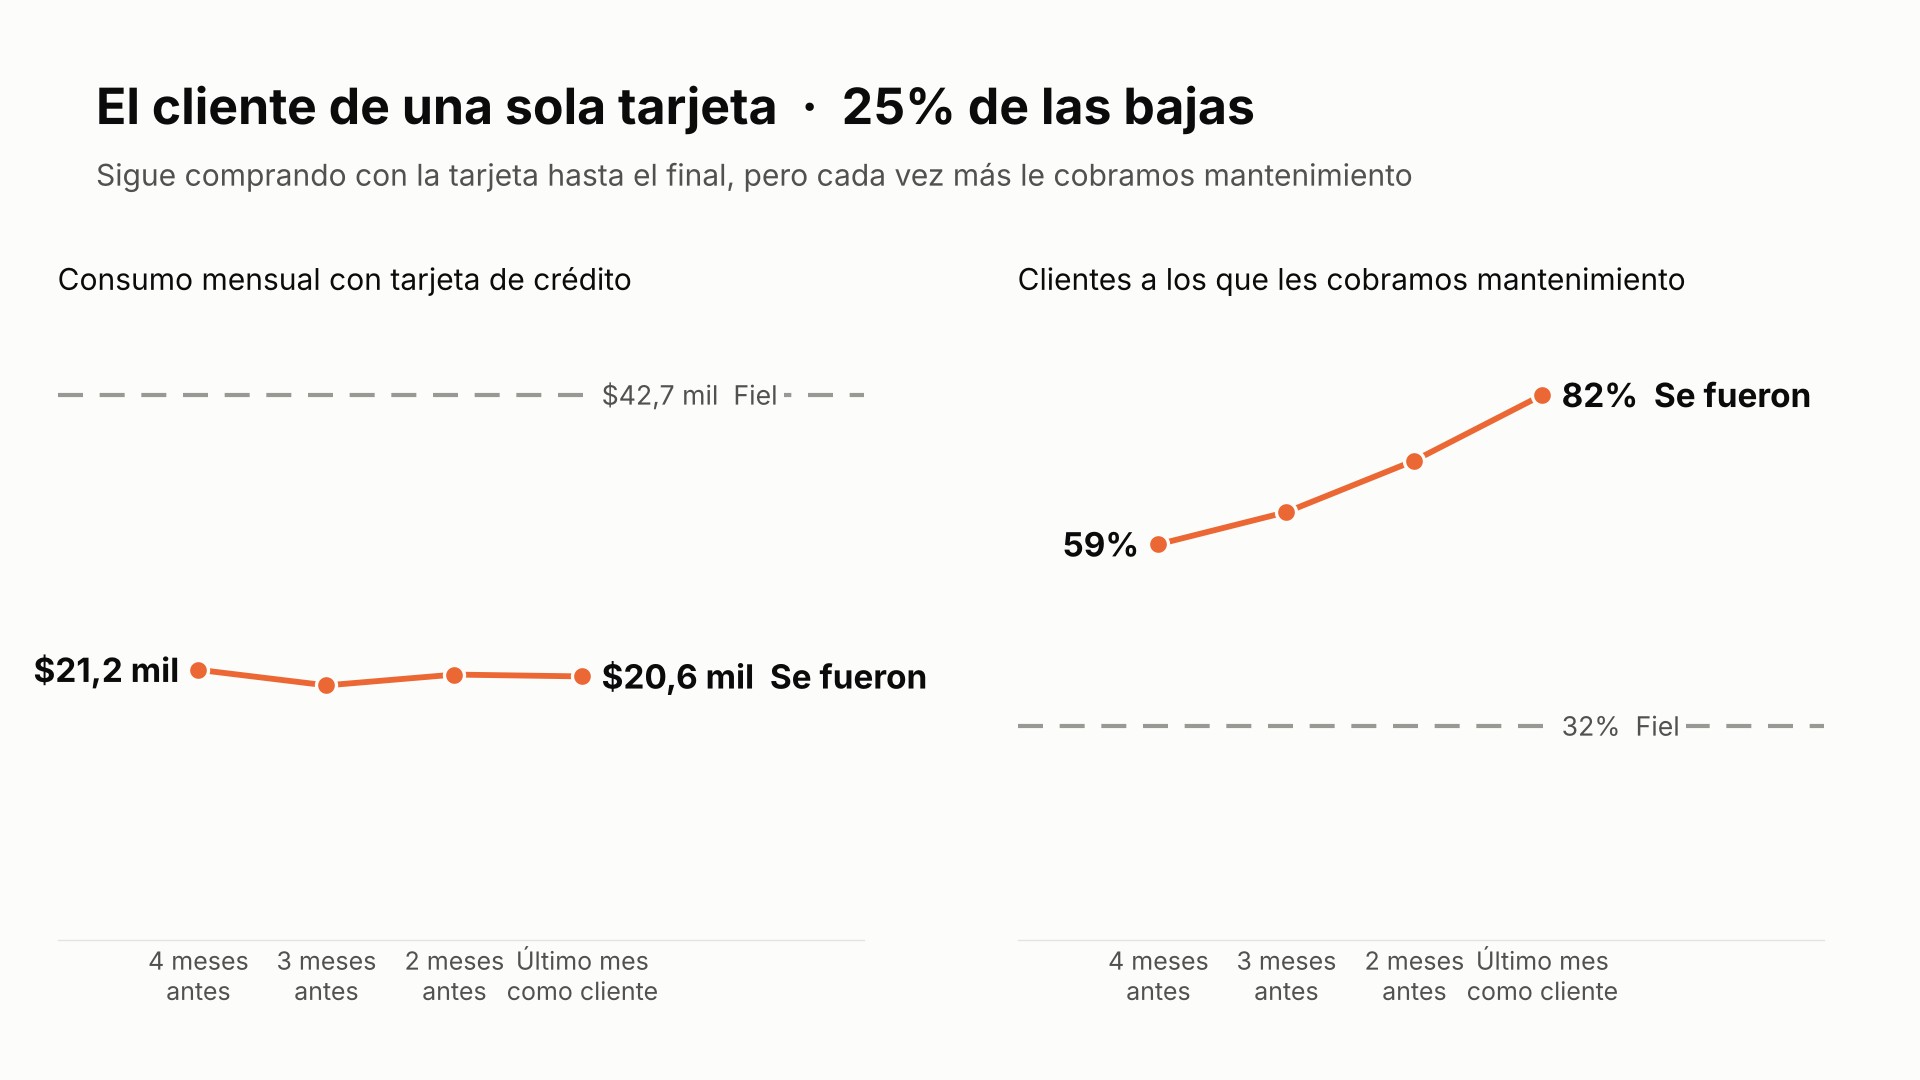

In [9]:
img("04_perfil_una_tarjeta.png")

### Perfil 3 · El endeudado sin red (18% de las bajas, 32% de la ganancia perdida)

**Quién es:** tiene préstamos personales (69%) o tarjeta en mora (35%), y no cobra el sueldo en el banco. Es el cliente **más rentable por cabeza** de los cinco: $19 mil por año, contra $13 mil del fiel.

**Variables que lo definen:**

- Rojo en cuenta corriente creciendo: **$16,6 mil → $29,3 mil** en 4 meses (+77%). Un fiel con préstamo está en ~$7 mil y estable.
- El **39%** de los que tienen préstamo tiene **5 o más** préstamos vigentes (fiel con préstamo: 16%).
- Sólo el **9%** de los que se fueron con préstamo cobraba el sueldo acá (fiel con préstamo: 60%).
- Sólo el **1%** había terminado de pagar sus préstamos dos meses antes de irse. La deuda queda en meseta (~$145-150 mil promedio) y recién en el último mes cae a la mitad.
- La mora en tarjeta pasa del 7% al 27%.

**La historia:** **no es el cliente que "terminó de pagar, quedó contento y se fue".** Se va en **meseta de sobre-endeudamiento**: muchos préstamos, ningún sueldo que los respalde, y un descubierto que tapa cuotas. La caída brusca de la deuda en el último mes sugiere que se cancela de golpe al salir — puede ser una refinanciación en otra entidad; los datos no permiten afirmarlo con certeza.

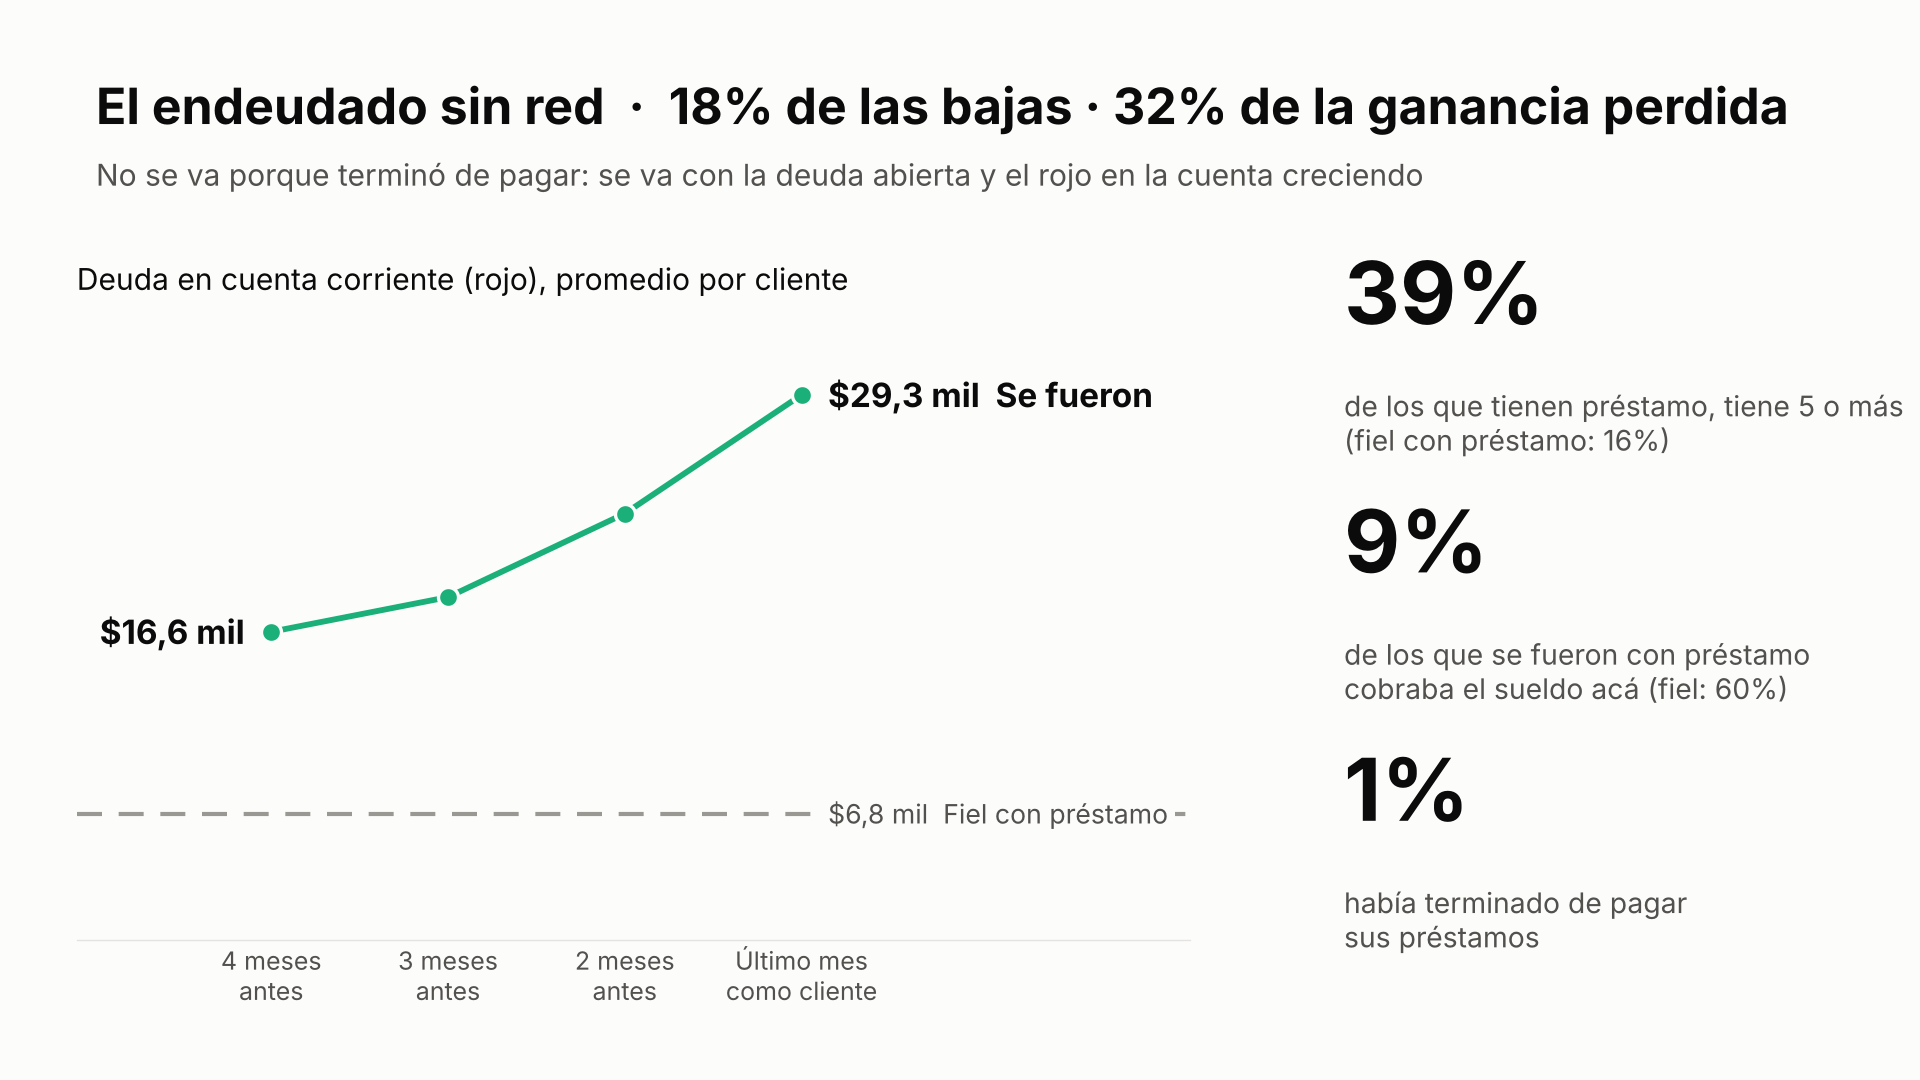

In [10]:
img("05_perfil_endeudado.png")

### Perfil 4 · El ahorrista digital castigado (16% de las bajas, 13% de la ganancia perdida)

**Quién es:** es el **más activo y digital** de los que se fueron: 71 movimientos por trimestre, 95% usa Homebanking/app, usa la tarjeta de débito todos los meses. El 59% tiene plazos fijos, inversiones o dólares — igual que un fiel. No cobra el sueldo en el banco.

**Variables que lo definen:**

- Le cobramos mantenimiento a una proporción cada vez mayor: **42% → 46% → 56% → 71%** (fiel: 32%, plano). Es la suba más fuerte de los cinco perfiles.
- Inversiones y ahorros: se mantienen en unos $280 mil promedio y en el último mes **caen a $184 mil (-34% en un mes)**.

**La historia:** es el cliente que cualquier banco digital quiere: no está desconectado, está **activo y con plata**. El disparador visible es que empieza a pagar mantenimiento — probablemente perdió alguna condición de bonificación, aunque los datos no dicen cuál. Ahí mueve sus ahorros y se va.

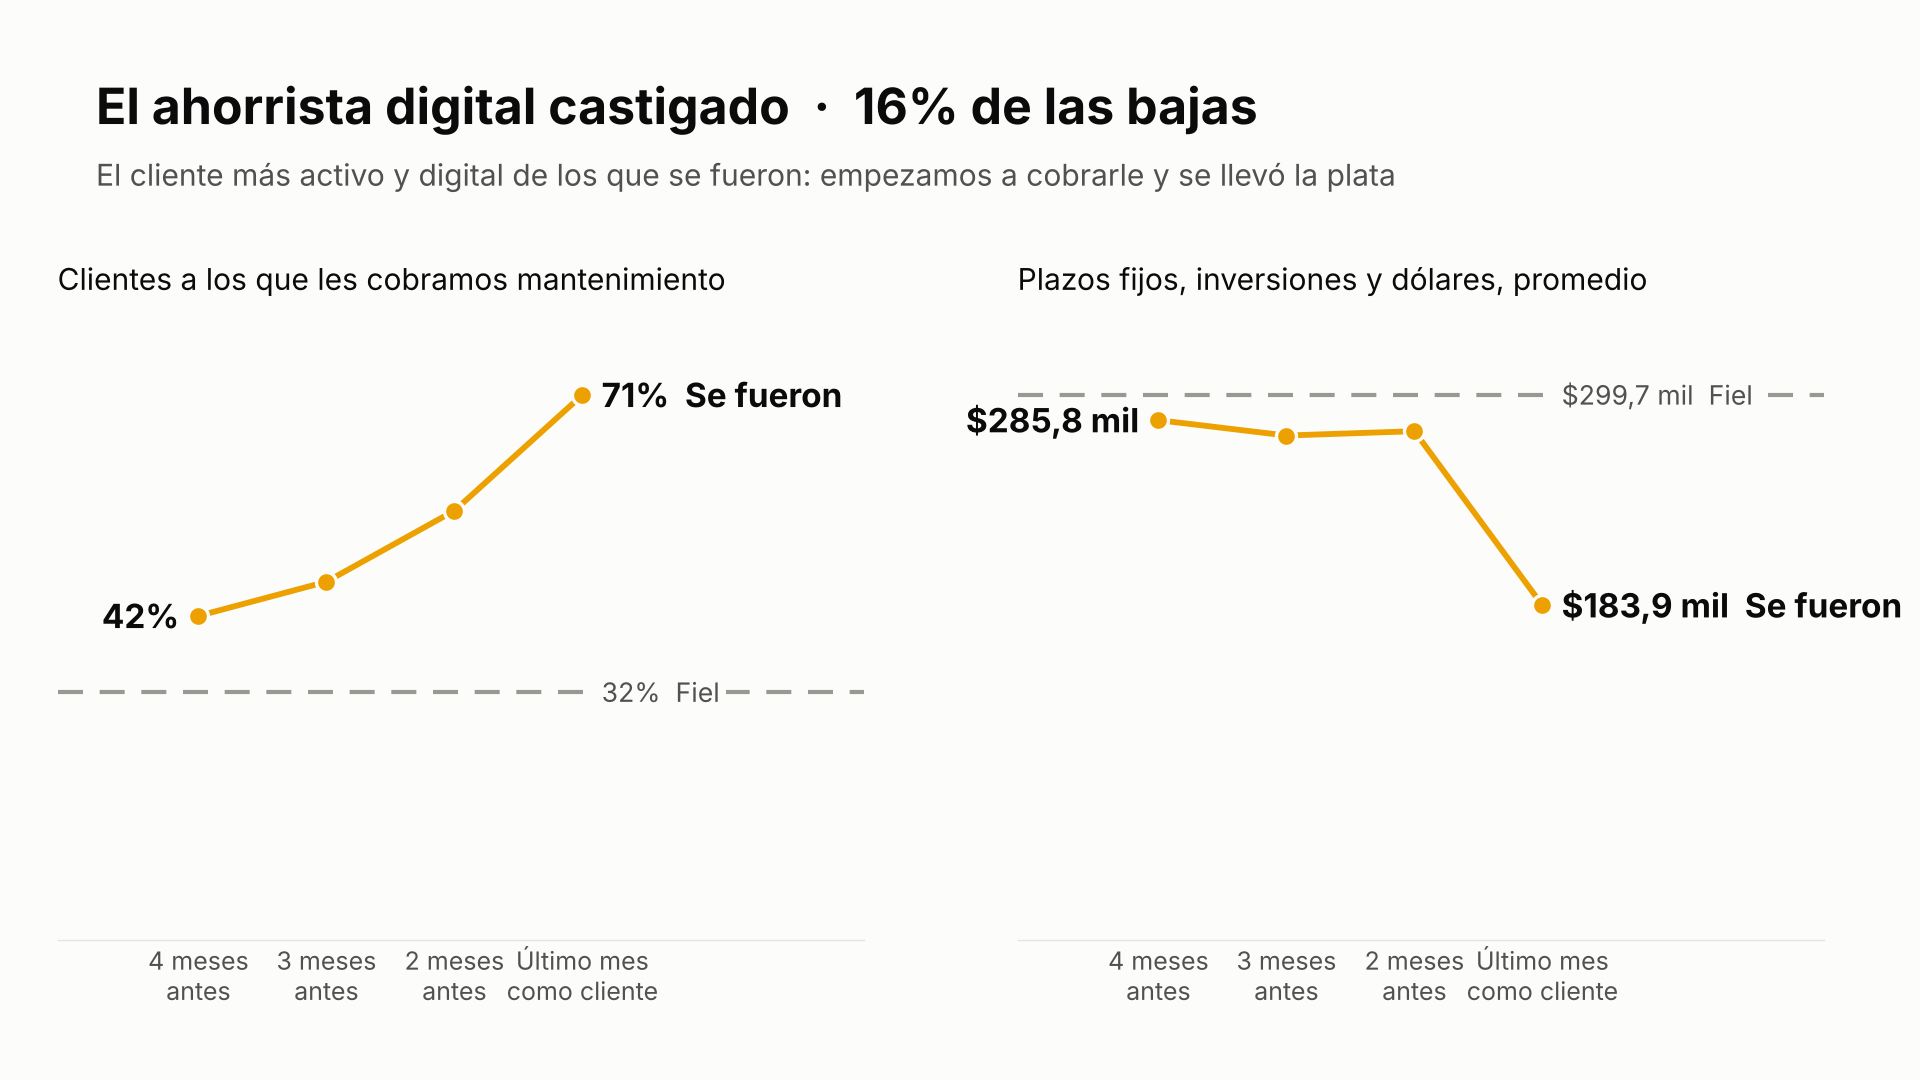

In [11]:
img("06_perfil_ahorrista_digital.png")

### Perfil 5 · El sueldo que se muda (11% de las bajas, 10% de la ganancia perdida)

**Quién es:** es el único perfil que cobraba el sueldo en el banco. Está activo (54 movimientos por trimestre), tiene buen saldo y casi no paga mantenimiento (22%), porque el sueldo lo bonifica.

**Variables que lo definen:**

- Cuántos siguen cobrando el sueldo acá: **83% → 69% → 57% → 36%** en los últimos 4 meses (fieles con sueldo: ~98% lo sigue cobrando).
- Los movimientos caen detrás del sueldo: de 88 a 66 por trimestre.

**La historia:** **primero se muda el sueldo, la cuenta se cierra después.** Hay una ventana de 2 a 3 meses entre la señal (deja de entrar el sueldo) y la baja — es la alerta temprana más clara y más simple de las cinco.

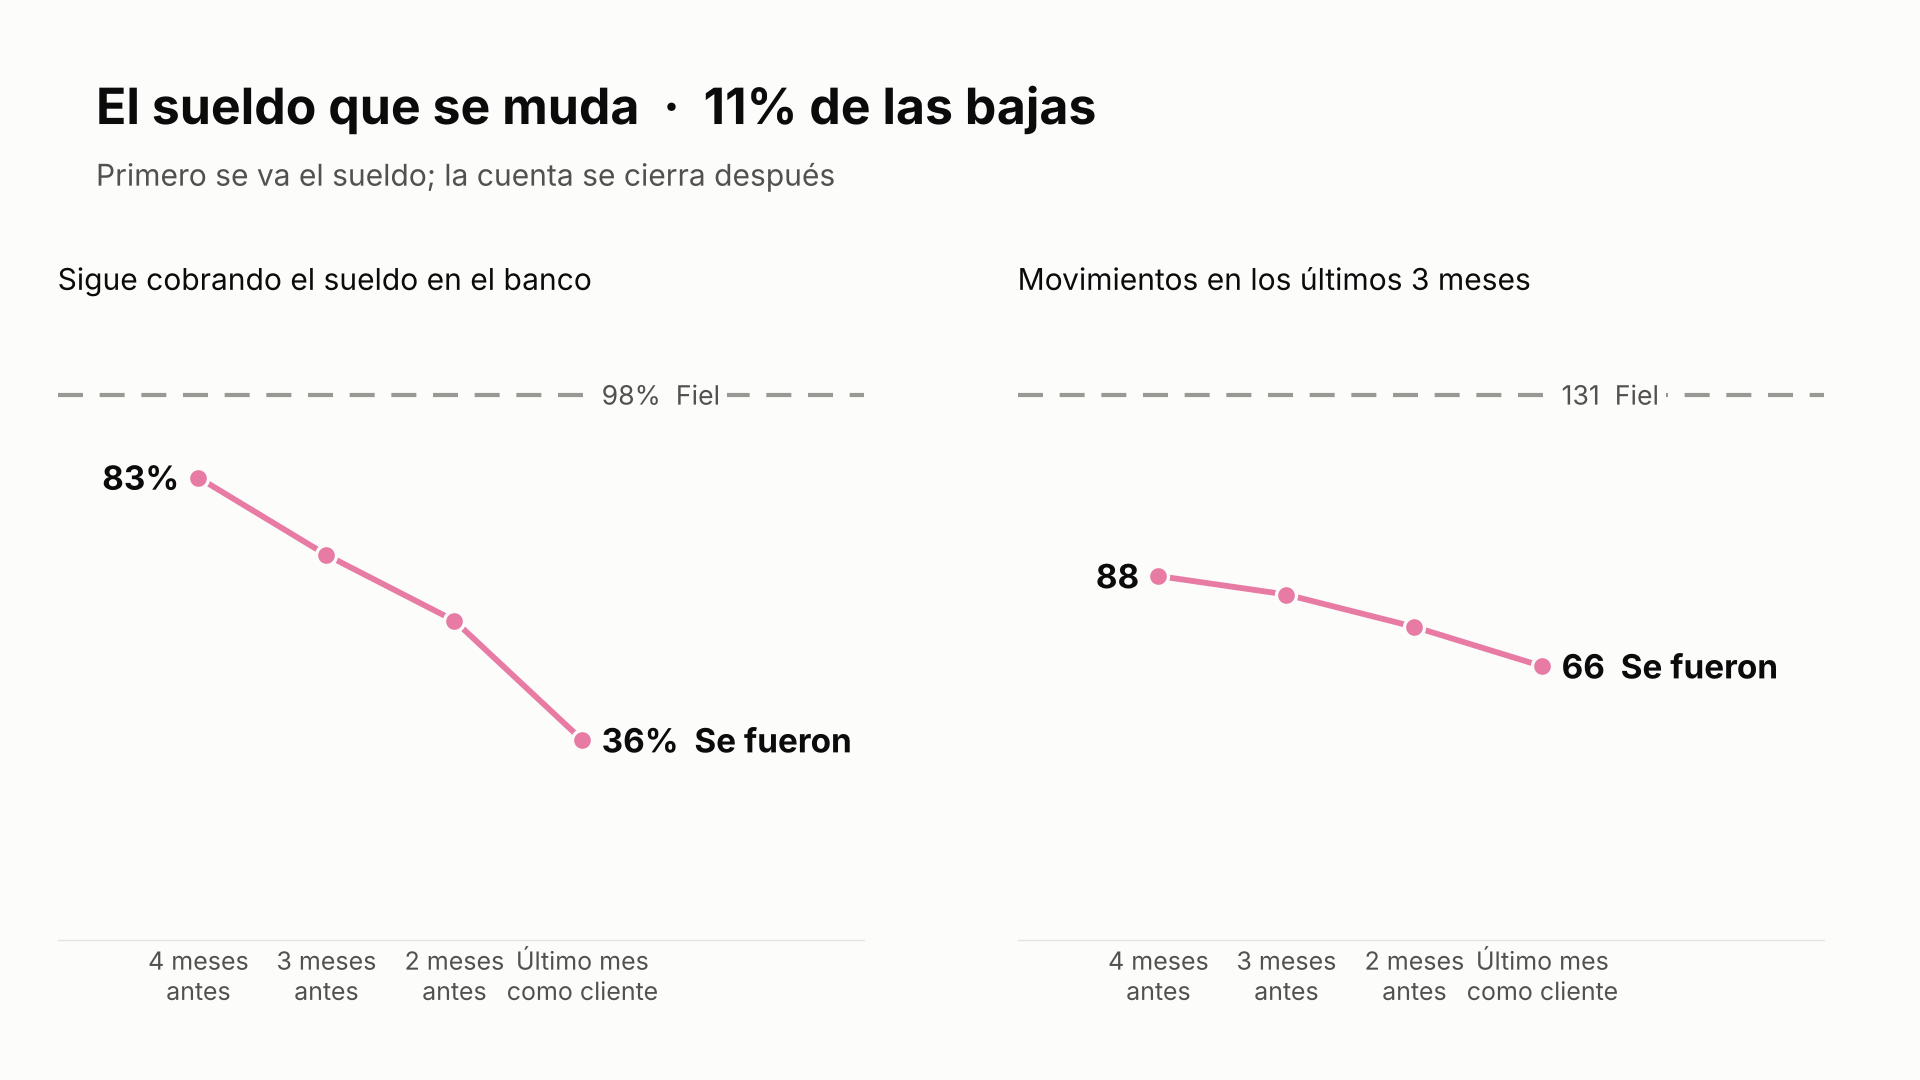

In [12]:
img("07_perfil_sueldo.png")

## 5. Plan operativo: alertas tempranas y a quién le toca actuar

Cada perfil tiene una señal que se puede monitorear **antes** de la baja, y pide una palanca distinta — y un dueño distinto dentro del banco. No es un plan para que todos hagan todo: es un plan para que cada equipo sepa qué le toca.


In [13]:
plan = pd.DataFrame([
    dict(Perfil="El fantasma que paga", Señal_temprana="Sin uso de débito ni crédito + descubierto creciendo + ya paga comisión",
         Acción="Pausar o eximir la comisión a cambio de activar débito o app; si no activa, pasarlo a una cuenta sin costo antes de que se vaya enojado",
         Equipo_principal="Canales Digitales", Equipo_apoyo="Red de Sucursales (contacto humano, ya que no usa canales propios)"),
    dict(Perfil="El cliente de una sola tarjeta", Señal_temprana="Sólo usa crédito, nunca débito, y empieza a pagar mantenimiento",
         Acción="Ofrecer un \"paquete tarjeta\" sin costo de mantenimiento, con cashback en sus rubros de consumo habituales",
         Equipo_principal="Red de Sucursales / Comercial de Tarjetas", Equipo_apoyo="—"),
    dict(Perfil="El endeudado sin red", Señal_temprana="Varios préstamos + rojo que crece mes a mes + mora incipiente",
         Acción="Reestructuración preventiva: unificar deuda en una cuota antes de que la refinancie otra entidad",
         Equipo_principal="Gestión de Riesgo Crediticio", Equipo_apoyo="Red de Sucursales (lleva la conversación con el cliente)"),
    dict(Perfil="El ahorrista digital castigado", Señal_temprana="Empieza a pagar mantenimiento siendo muy activo y con inversiones",
         Acción="Alerta automática para bonificar al cliente digital con inversiones; premio por saldo invertido antes de que mueva la plata",
         Equipo_principal="Canales Digitales", Equipo_apoyo="Comercial de Inversiones"),
    dict(Perfil="El sueldo que se muda", Señal_temprana="Deja de entrar el sueldo (un solo mes ya es señal)",
         Acción="Alerta a la sucursal o al oficial de cuenta; contacto en la ventana de 2 a 3 meses, con beneficios de portabilidad del sueldo",
         Equipo_principal="Red de Sucursales", Equipo_apoyo="—"),
]).set_index("Perfil")
plan.columns = ["Señal temprana", "Acción", "Equipo responsable", "Equipo de apoyo"]

(plan.style
    .set_properties(**{"text-align": "left", "white-space": "pre-wrap"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "left")]},
                        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"), ("text-align", "left")]}])
    .set_caption("Matriz de alertas tempranas y acciones por perfil"))


,Señal temprana,Acción,Equipo responsable,Equipo de apoyo
Perfil,,,,
El fantasma que paga,Sin uso de débito ni crédito + descubierto creciendo + ya paga comisión,"Pausar o eximir la comisión a cambio de activar débito o app; si no activa, pasarlo a una cuenta sin costo antes de que se vaya enojado",Canales Digitales,"Red de Sucursales (contacto humano, ya que no usa canales propios)"
El cliente de una sola tarjeta,"Sólo usa crédito, nunca débito, y empieza a pagar mantenimiento","Ofrecer un ""paquete tarjeta"" sin costo de mantenimiento, con cashback en sus rubros de consumo habituales",Red de Sucursales / Comercial de Tarjetas,—
El endeudado sin red,Varios préstamos + rojo que crece mes a mes + mora incipiente,Reestructuración preventiva: unificar deuda en una cuota antes de que la refinancie otra entidad,Gestión de Riesgo Crediticio,Red de Sucursales (lleva la conversación con el cliente)
El ahorrista digital castigado,Empieza a pagar mantenimiento siendo muy activo y con inversiones,Alerta automática para bonificar al cliente digital con inversiones; premio por saldo invertido antes de que mueva la plata,Canales Digitales,Comercial de Inversiones
El sueldo que se muda,Deja de entrar el sueldo (un solo mes ya es señal),"Alerta a la sucursal o al oficial de cuenta; contacto en la ventana de 2 a 3 meses, con beneficios de portabilidad del sueldo",Red de Sucursales,—


**Cómo se reparten los tres frentes:**

- **Red de Sucursales (~1.000 comerciales):** dueña de las conversaciones que requieren trato humano — portabilidad de sueldo, reestructuración de deuda, y el contacto de rescate del "fantasma" que no usa ningún canal propio. Es el equipo con más perfiles bajo su radar (4 de 5), pero sólo como responsable único en 2.
- **Canales Digitales:** dueña de las alertas automáticas y ofertas in-app — el "fantasma" (activación) y el "ahorrista digital" (el perfil que vive ahí). Es más barato y más rápido de activar que una llamada, pero sólo funciona en los perfiles que todavía tocan un canal digital.
- **Gestión de Riesgo Crediticio:** dueña de un solo perfil, pero es el de mayor impacto económico individual — el "endeudado sin red" (32% de la ganancia perdida con sólo 18% de las bajas). Acá la conversación no es comercial, es de reestructuración de deuda.

El perfil **"una sola tarjeta"** es el único que no depende de una alerta temprana por comportamiento — el disparador es la propia política de precios del banco (cuándo empieza a cobrarle mantenimiento), así que la palanca más efectiva es revisar esa política antes de que el cliente la sienta.
